# Naive Bayes From Scratch

Implemented using **NumPy** — `sklearn` is only used to load the Breast Cancer dataset.

In this notebook we implement **Gaussian Naive Bayes from scratch**, covering:
- What Naive Bayes is and the assumption it makes
- **Bayes' Theorem** — the math behind the prediction
- **Gaussian Likelihood** — modeling continuous features
- **Log-space computation** — avoiding numerical underflow
- A clean, reusable `NaiveBayes` class with `fit` and `predict`
- Our own **`train_test_split`** — no sklearn utilities

Resources that helped me build this:

Video — Intuition & Implementation: https://youtu.be/TLInuAorxqE?si=zJFGPpMtlipiBCXg

## What is Naive Bayes?

**Naive Bayes** is a probabilistic classifier built on **Bayes' Theorem**.

Given a feature vector $\mathbf{x}$, we want to find the class $c$ that maximizes the **posterior probability**:

$$P(c \mid \mathbf{x}) = \frac{P(\mathbf{x} \mid c) \; P(c)}{P(\mathbf{x})}$$

Since $P(\mathbf{x})$ is constant across all classes, we just maximize the numerator:

$$\hat{c} = \arg\max_c \; P(\mathbf{x} \mid c) \; P(c)$$

Where:
- $P(c)$ is the **prior** — how common is class $c$ in the training data?
- $P(\mathbf{x} \mid c)$ is the **likelihood** — how probable is this feature vector given class $c$?

### The "Naive" assumption

Computing $P(\mathbf{x} \mid c)$ for a 30-dimensional vector directly is intractable. Naive Bayes makes a bold **conditional independence assumption**: features are independent given the class label.

$$P(\mathbf{x} \mid c) = \prod_{j=1}^{n} P(x_j \mid c)$$

This is "naive" because it's almost never literally true — but it works surprisingly well in practice.

### Gaussian Naive Bayes

For continuous features we model each $P(x_j \mid c)$ as a **Gaussian (Normal) distribution**:

$$P(x_j \mid c) = \frac{1}{\sqrt{2\pi}\,\sigma_{jc}} \exp\!\left(-\frac{(x_j - \mu_{jc})^2}{2\sigma_{jc}^2}\right)$$

where $\mu_{jc}$ and $\sigma_{jc}$ are the mean and std of feature $j$ among training samples of class $c$.

Let's start coding 🤓 .

##1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer  # only used to load the dataset

## 2. Load & Explore Data

We use the **Breast Cancer Wisconsin** dataset — 569 samples, 30 features, 2 classes:
- **Benign (B)** — non-cancerous
- **Malignant (M)** — cancerous

We load it straight from sklearn and keep everything as NumPy arrays.

In [2]:
bc = load_breast_cancer()

X = bc.data                             # shape (569, 30)
y = np.where(bc.target == 1, "B", "M") # 1 → Benign, 0 → Malignant

FEATURE_NAMES = bc.feature_names

print(f"Dataset shape : {X.shape}")
print(f"Classes       : {np.unique(y)}")
print(f"Class counts  : B={np.sum(y == 'B')}, M={np.sum(y == 'M')}")

Dataset shape : (569, 30)
Classes       : ['B' 'M']
Class counts  : B=357, M=212


## 3. Train / Test Split — From Scratch

Same implementation .

In [3]:
def train_test_split(X, y, test_size=0.2, random_state=None):
    """
    Randomly split X and y into train and test sets.

    test_size    : fraction of data used for testing (default 0.2)
    random_state : seed for reproducibility
    """
    if random_state is not None:
        np.random.seed(random_state)

    m = len(y)
    indices = np.random.permutation(m)

    split = int(m * (1 - test_size))
    train_idx, test_idx = indices[:split], indices[split:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train size : {len(y_train)}")
print(f"Test  size : {len(y_test)}")

Train size : 455
Test  size : 114


## 4. A Note on Numerical Underflow

With 30 features, the likelihood product becomes:

$$P(\mathbf{x} \mid c) = \prod_{j=1}^{30} P(x_j \mid c)$$

Each individual $P(x_j \mid c)$ is a small probability. Multiplying 30 small numbers together can produce values so tiny that floating-point arithmetic rounds them to **zero** — this is called **numerical underflow**.

The standard fix: take the **log** of everything.

$$\log P(\mathbf{x} \mid c) + \log P(c) = \sum_{j=1}^{n} \log P(x_j \mid c) + \log P(c)$$

Since $\log$ is a monotonically increasing function, maximizing the log-posterior gives the same result as maximizing the posterior — but without any underflow risk.

$$\log P(x_j \mid c) = -\log(\sqrt{2\pi}\,\sigma_{jc}) - \frac{(x_j - \mu_{jc})^2}{2\sigma_{jc}^2}$$

## 5. The NaiveBayes Class

**`fit`** — for each class, compute:
- The **prior** $\log P(c)$ from label frequencies
- The **mean** $\mu_{jc}$ of every feature
- The **std** $\sigma_{jc}$ of every feature

**`predict`** — for each sample (vectorized over the full test set at once):
1. Compute the **log-likelihood** of each feature under each class Gaussian
2. Sum across features (product in original space → sum in log space)
3. Add the log-prior
4. Return the class with the highest log-posterior

Everything is vectorized — no Python loop over samples or features.

In [4]:
class NaiveBayes:
  def fit(self, X, y):
    """
    compute per-class priors and likelihoods from training data
    """

    self.classes, counts = np.unique(y, return_counts=True)
    self.log_priors = np.log(counts / counts.sum())

    self.means = np.array([X[y == c].mean(axis=0) for c in self.classes])
    self.stds = np.array([X[y == c].std(axis=0) for c in self.classes])

    return self

  def _log_likelihood(self, X):
    """
    compute the log-likelihood of each feature under each class
    """
    X_exp = X[:, np.newaxis, :]
    means = self.means[np.newaxis, :, :]
    stds = self.stds[np.newaxis, :, :]

    log_p = (
            -np.log(np.sqrt(2 * np.pi) * stds)
            - ((X_exp - means) ** 2) / (2 * stds ** 2)
        )

    return log_p.sum(axis=2)

  def predict(self, X):
    """
    Return predicted class labels for each row in X.
    """
    log_p = self._log_likelihood(X) + self.log_priors
    return self.classes[np.argmax(log_p, axis=1)]


##6. Train and Evaluate

In [5]:
model = NaiveBayes()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
accuracy    = np.mean(predictions == y_test) * 100
print(f"Test accuracy: {accuracy:.2f}%")

Test accuracy: 92.98%


## 7. Visualize the Learned Gaussians

Naive Bayes fits a Gaussian to each feature for each class during training.
Here we plot the learned distributions for the two most informative features
(**radius mean** and **texture mean**) to see how well the two classes separate.

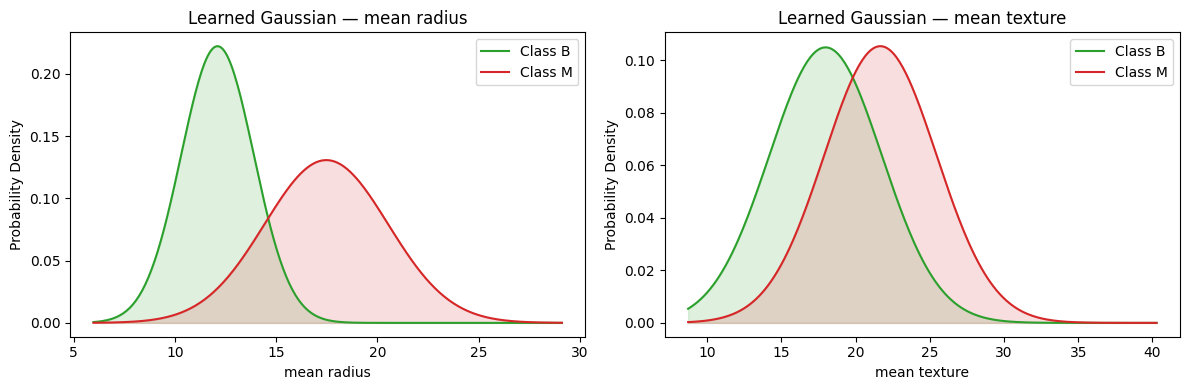

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = {"B": "tab:green", "M": "tab:red"}
feature_indices = [0, 1]   # radius mean, texture mean

for ax, fi in zip(axes, feature_indices):
    x_range = np.linspace(X[:, fi].min() - 1, X[:, fi].max() + 1, 300)

    for i, cls in enumerate(model.classes):
        mu  = model.means[i, fi]
        sig = model.stds[i, fi]
        pdf = (1 / (np.sqrt(2 * np.pi) * sig)) * np.exp(-0.5 * ((x_range - mu) / sig) ** 2)
        ax.plot(x_range, pdf, color=colors[cls], label=f"Class {cls}")
        ax.fill_between(x_range, pdf, alpha=0.15, color=colors[cls])

    ax.set_xlabel(FEATURE_NAMES[fi])
    ax.set_ylabel("Probability Density")
    ax.set_title(f"Learned Gaussian — {FEATURE_NAMES[fi]}")
    ax.legend()

plt.tight_layout()
plt.show()